In [94]:
import pandas as pd
import sqlite3
import datetime
from os import path
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from functools import reduce

In [32]:

#--------Directories ---------------------------------------
## Project directory
project_dir = path.dirname(path.dirname(path.abspath('')))

## Location of database files
db_dir = path.join(project_dir,"files", "data", "lfs", "UWB")

## Location for Graphs
graph_dir = path.join(project_dir, "files", "data", "lfs","UWB",  "graphs")

metadata_dir = path.join(project_dir, "files", "data", "lfs","UWB", "metadata")

In [33]:
def generate_lineplot(df, select_date_start=None, select_date_end=None, component=None,
                      scope=None, save_fig=True, graphs_dir=graph_dir,
                      stations_meta=None, components_meta=None):

    # --- Date range ---
    start = select_date_start if select_date_start else str(df['date_start'].iloc[0])
    end   = select_date_end   if select_date_end   else str(df['date_start'].iloc[-1])

    df_plt = df.query(f'date_start >= "{start}" and date_start < "{end}"').copy()

    # --- Metadata lookups ---
    # Component info
    comp_name, comp_symbol, comp_unit = "Unknown", "", ""
    if components_meta is not None and component is not None:
        row = components_meta[components_meta['component_id'] == component]
        if not row.empty:
            comp_name   = row['component_name'].values[0]
            comp_symbol = row['component_symbol'].values[0]
            comp_unit   = row['component_unit'].values[0]

    # Station label map: station_id → "CODE – Name"
    label_map = {}
    if stations_meta is not None:
        for sid in df_plt['station_id'].unique():
            row = stations_meta[stations_meta['station_id'] == sid]
            if not row.empty:
                code = row['station_code'].values[0]
                name = row['station_name'].values[0]
                label_map[sid] = f"{code} – {name}"
            else:
                label_map[sid] = str(sid)

    df_plt['station_label'] = df_plt['station_id'].map(label_map).fillna(df_plt['station_id'].astype(str))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(40, 10))

    sns.lineplot(data=df_plt, x="date_start", y="value",
                 hue="station_label", ax=ax, linewidth=1.2)

    # Title
    date_range_str = f"{start[:10]}  →  {end[:10]}"
    ax.set_title(
        f"{comp_name} ({comp_symbol})  |  {date_range_str}",
        fontsize=18, fontweight='bold', pad=16
    )

    # Axis labels
    ax.set_xlabel("Datum", fontsize=13)
    ax.set_ylabel(f"{comp_symbol}  [{comp_unit}]", fontsize=13)

    # Legend
    ax.legend(
        title="Messstation",
        title_fontsize=12,
        fontsize=11,
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        borderaxespad=0,
        frameon=True
    )

    ax.xaxis.set_major_formatter(
        plt.matplotlib.dates.DateFormatter('%Y-%m-%d')
    )
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()

    # --- Save ---
    if save_fig:
        plt_name = f'UWB_{comp_symbol}_{start[:10]}--{end[:10]}.pdf'
        file_path = path.join(graph_dir, plt_name)
        fig.savefig(file_path, bbox_inches='tight')

    plt.show()

In [34]:
def heatmap_missing_values(df, save_fig = True, graphs_dir=graph_dir, component = None):
    # Create a boolean mask for null values
    null_mask = df.isna()

    # Create the heatmap
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.heatmap(null_mask, 
                cbar_kws={'label': 'Missing Data'},
                cmap='viridis', ax=ax)
    plt.title('Missing Values Heatmap', fontsize=16, pad=20)
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Rows', fontsize=12)
    plt.tight_layout()

    # --- Save ---
    if save_fig:
        if component == None:
            plt_name = f'Missing_values_heatmap.png'
        else:
            plt_name = f'Missing_values_heatmap_comp-{component}.png'
        file_path = path.join(graph_dir, plt_name)
        fig.savefig(file_path, bbox_inches='tight')

        
    plt.show()

In [35]:
def filter_db_files(
        station_id: int | None = None,
        component: int | None = None,
        scope: int | None = None,
        min_filesize: int = 20000,
        file_type: str = "db"
    ) -> list:
    if station_id == None:
        station_id ="*"

    if component == None:
        component = "*"

    if scope == None:
        scope = "*"

    mask = f'station_{station_id}*_comp_{component}*_scope_{scope}*{file_type}'
    files = glob.glob(path.join(db_dir, mask))
    files_filterd = []
    for file in files:
        if path.getsize(file) >= min_filesize:
            files_filterd.append(file)
    return files_filterd

In [36]:
def load_dbs(
        station_id: int | None = None,
        component: int | None = None,
        scope: int | None = None,
        min_filesize: int = 20000,
        file_type: str = "db",
        project_dir: str = 'files/data/lfs/UWB'
    ) -> list:
    dfs = []
    files = filter_db_files(station_id, component, scope, min_filesize, file_type)
    for file in files:
        conn = sqlite3.connect(file)
        df = pd.read_sql_query("SELECT * FROM measurements", conn)
        dfs.append(df)
    df = pd.concat(dfs,ignore_index=True)

    # 1. Identify which rows have the 24:00:00 problem
    mask = df["date_end"].str.contains("24:00:00")

    # 2. Replace 24:00:00 with 00:00:00 so pandas can parse it
    df["date_end"] = df["date_end"].str.replace("24:00:00", "00:00:00")

    # 3. Convert to datetime
    df["date_end"] = pd.to_datetime(df["date_end"])

    # 4. Add exactly 1 day to the rows that originally had 24:00:00
    df.loc[mask, "date_end"] += pd.Timedelta(days=1)
    df["date_start"] = pd.to_datetime(df["date_start"])
    df["date_end"] = pd.to_datetime(df["date_end"])
    df["station_id"] = df["station_id"].astype(str)
    df = df.drop("index_value", axis=1)

    return df

In [ ]:
#------ Drop stations withouth full range of dates

def drop_incomplete_stations(df, select_date_start='2018-01-01', select_date_end='2025-12-31 23:00:00'):

    '''
    Drop all measurement stations from the dataset that don't 
    cover measurements the specified range 
    '''
    # stations whose minimum start‑date is after 2018‑01‑01
    min_dates = df.groupby('station_id')['date_start'].min()
    max_dates = df.groupby('station_id')['date_start'].max()

    min_index =list(min_dates[min_dates > select_date_start].index)
    max_index =list(max_dates[max_dates < select_date_end].index)

    drop_index = min_index+ max_index

    # keep only rows whose station_id is **not** in the drop_index list
    df = df[~df["station_id"].isin(drop_index)]
    print("Stations dropped: ", drop_index)

    return df

In [84]:
## Load the Measurement data
df = load_dbs("857", component="*", scope="2", project_dir=db_dir)

unique_components = df["component_id"].unique()
print(unique_components)
unique_scopes = df["scope_id"].unique()
print(unique_scopes)

[5 4 1]
[2]


In [105]:
frames =[]
for component in unique_components:
    df_c = df[df["component_id"] ==component]
    df_c.rename(columns={'value':component}, inplace=True)
    df_c.drop(columns=['component_id', 'station_id', 'scope_id', 'date_end'], inplace=True)
    frames.append(df_c)
    print(df_c.head())

merged_df = reduce(
    lambda left, right: pd.merge(left, right, on='date_start', how='left'), 
    frames
)

merged_df =merged_df.set_index(keys='date_start')
merged_df.info()

           date_start     5
0 2018-01-01 00:00:00  39.0
1 2018-01-01 01:00:00  16.0
2 2018-01-01 02:00:00   8.0
3 2018-01-01 03:00:00  10.0
4 2018-01-01 04:00:00  12.0
               date_start     4
70128 2018-01-01 00:00:00   6.0
70129 2018-01-01 01:00:00   3.0
70130 2018-01-01 02:00:00   3.0
70131 2018-01-01 03:00:00  10.0
70132 2018-01-01 04:00:00  14.0
                date_start     1
140256 2018-01-01 00:00:00  12.0
140257 2018-01-01 01:00:00  22.0
140258 2018-01-01 02:00:00  12.0
140259 2018-01-01 03:00:00  15.0
140260 2018-01-01 04:00:00  15.0
<class 'pandas.DataFrame'>
DatetimeIndex: 70128 entries, 2018-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   5       69198 non-null  float64
 1   4       69611 non-null  float64
 2   1       68471 non-null  float64
dtypes: float64(3)
memory usage: 2.1 MB


In [40]:
## Load the metadata
stations_meta    = pd.read_csv(path.join(metadata_dir,"UWB_stations_metadata.csv"))
stations_meta['station_id'] = stations_meta['station_id'].astype(str)
components_meta  = pd.read_csv(path.join(metadata_dir,"UWB_components_metadata.csv"))

In [41]:
components_meta.head()

,component_id,component_code,component_symbol,component_unit,component_name
0,1,PM10,PM₁₀,µg/m³,Feinstaub
1,2,CO,CO,mg/m³,Kohlenmonoxid
2,3,O3,O₃,µg/m³,Ozon
3,4,SO2,SO₂,µg/m³,Schwefeldioxid
4,5,NO2,NO₂,µg/m³,Stickstoffdioxid


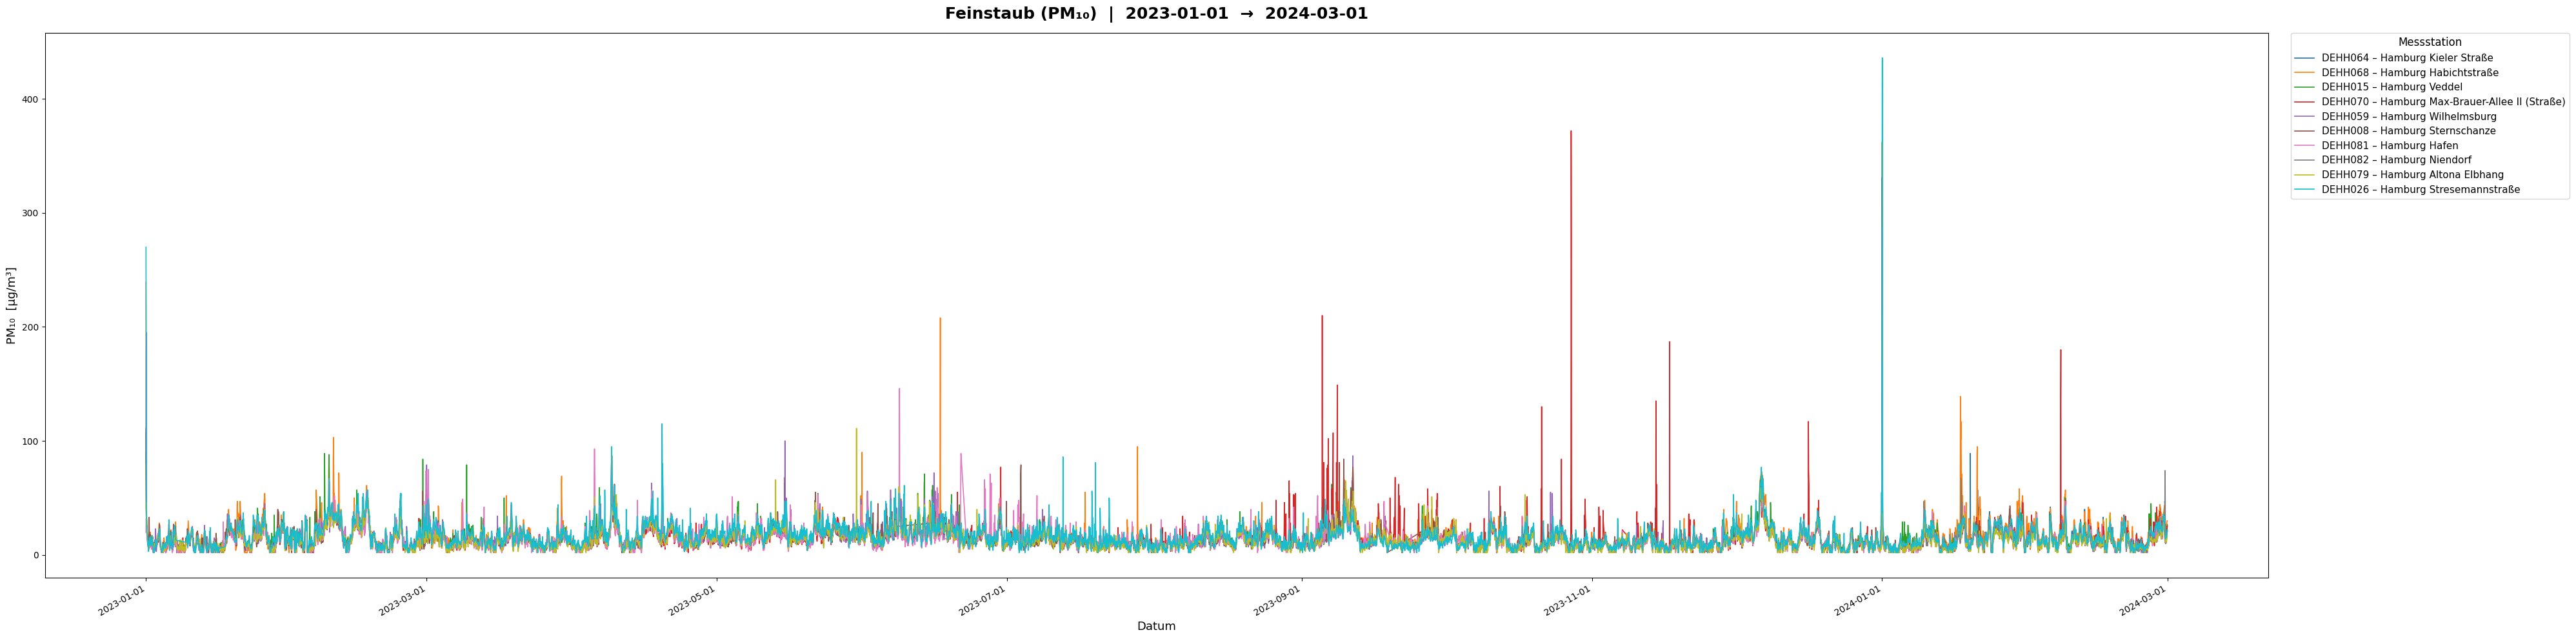

In [ ]:

generate_lineplot(
    df,
    select_date_start="2023-01-01",
    select_date_end="2024-03-01",
    component=1,                      # 1 = PM10 / Feinstaub
    stations_meta=stations_meta,
    components_meta=components_meta,
)

In [42]:
df.head()

,date_start,date_end,station_id,component_id,scope_id,value
0,2018-01-01 00:00:00,2018-01-01 01:00:00,857,5,2,39.0
1,2018-01-01 01:00:00,2018-01-01 02:00:00,857,5,2,16.0
2,2018-01-01 02:00:00,2018-01-01 03:00:00,857,5,2,8.0
3,2018-01-01 03:00:00,2018-01-01 04:00:00,857,5,2,10.0
4,2018-01-01 04:00:00,2018-01-01 05:00:00,857,5,2,12.0


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 280512 entries, 0 to 280511
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date_start    280512 non-null  datetime64[us]
 1   date_end      280512 non-null  datetime64[us]
 2   station_id    280512 non-null  str           
 3   component_id  280512 non-null  int64         
 4   scope_id      280512 non-null  int64         
 5   value         276397 non-null  float64       
dtypes: datetime64[us](2), float64(1), int64(2), str(1)
memory usage: 12.8 MB


In [44]:
# Filter for stations in Hamburg
stations_meta_ham = stations_meta[stations_meta["network_name"]=="Hamburg"]
stations_meta_ham.set_index('station_id',inplace=True)

In [45]:
stations_meta_ham.loc['857']

station_code                        DEHH081
station_name                  Hamburg Hafen
station_city                        Hamburg
station_synonym                         NaN
station_active_from              2015-09-29
station_active_to                       NaN
station_longitude                    9.9816
station_latitude                    53.5292
network_id                                6
station_setting_id                        1
station_type_id                           1
network_code                             HH
network_name                        Hamburg
station_setting_name             urban area
station_setting_short_name            urban
station_type_name                background
station_street                    Worthdamm
station_street_nr                        49
station_zip_code                      20457
Name: 857, dtype: object

In [46]:
components  = [1, 2, 3, 4, 5]

In [47]:
frames = []
for component in components:
    df = load_dbs('*', component=str(component), scope='*')
    frames.append(df)


In [49]:
df_hafen = pd.concat(frames)

In [51]:
df_hafen["station_id"].unique()

<StringArray>
[  '840',   '844',   '791',   '846',   '835',   '784',   '857', '10348',
   '802',   '855',   '826', '10466']
Length: 12, dtype: str

In [ ]:
df_hafen.head()

,date_start,date_end,station_id,component_id,scope_id,value
0,2024-01-01 00:00:00,2024-01-01 01:00:00,840,1,6,NaN
1,2024-01-01 01:00:00,2024-01-01 02:00:00,840,1,6,NaN
2,2024-01-01 02:00:00,2024-01-01 03:00:00,840,1,6,NaN
3,2024-01-01 03:00:00,2024-01-01 04:00:00,840,1,6,NaN
4,2024-01-01 04:00:00,2024-01-01 05:00:00,840,1,6,NaN


In [ ]:
df_hafen.tail()

,date_start,date_end,station_id,component_id,scope_id,value
736363,2025-12-31 19:00:00,2025-12-31 20:00:00,846,5,2,24.0
736364,2025-12-31 20:00:00,2025-12-31 21:00:00,846,5,2,21.0
736365,2025-12-31 21:00:00,2025-12-31 22:00:00,846,5,2,24.0
736366,2025-12-31 22:00:00,2025-12-31 23:00:00,846,5,2,15.0
736367,2025-12-31 23:00:00,2026-01-01 00:00:00,846,5,2,9.0


In [ ]:
df_hafen.groupby('station_id')['date_start'].min()

station_id
10348   2024-01-01
10466   2024-01-01
784     2018-01-01
791     2018-01-01
802     2018-01-01
826     2018-01-01
835     2018-01-01
840     2018-01-01
844     2018-01-01
846     2018-01-01
855     2018-01-01
857     2018-01-01
Name: date_start, dtype: datetime64[us]

In [55]:
df_hafen['station_id'].unique()

<StringArray>
['840', '844', '791', '846', '835', '784', '857', '802', '855', '826']
Length: 10, dtype: str

In [21]:
df_hafen.groupby("station_id").describe()

date_start                                                   \
                count                        mean                  min   
station_id                                                               
784            350640         2021-12-31 23:30:00  2018-01-01 00:00:00   
791            280512         2021-12-31 23:30:00  2018-01-01 00:00:00   
802            210384         2021-12-31 23:30:00  2018-01-01 00:00:00   
826            140256         2021-12-31 23:30:00  2018-01-01 00:00:00   
835            281256  2022-01-04 19:16:11.806468  2018-01-01 00:00:00   
840            105216  2023-01-01 07:29:53.430657  2018-01-01 00:00:00   
844            292194  2021-12-26 12:10:56.070966  2018-01-01 00:00:00   
846            292194  2021-12-26 12:10:56.070966  2018-01-01 00:00:00   
855            280512         2021-12-31 23:30:00  2018-01-01 00:00:00   
857            280512         2021-12-31 23:30:00  2018-01-01 00:00:00   

                                                                           \
                            25%                  50%                  75%   
station_id                                                                  
784         2020-01-01 11:45:00  2021-12-31 23:30:00  2024-01-01 11:15:00   
791         2020-01-01 11:45:00  2021-12-31 23:30:00  2024-01-01 11:15:00   
802         2020-01-01 11:45:00  2021-12-31 23:30:00  2024-01-01 11:15:00   
826         2020-01-01 11:45:00  2021-12-31 23:30:00  2024-01-01 11:15:00   
835         2020-01-03 10:00:00  2022-01-04 20:30:00  2024-01-07 07:00:00   
840         2020-12-31 23:45:00  2024-01-01 07:30:00  2024-12-31 15:15:00   
844         2020-01-24 01:15:00  2021-11-25 19:00:00  2023-12-09 21:45:00   
846         2020-01-24 01:15:00  2021-11-25 19:00:00  2023-12-09 21:45:00   
855         2020-01-01 11:45:00  2021-12-31 23:30:00  2024-01-01 11:15:00   
857         2020-01-01 11:45:00  2021-12-31 23:30:00  2024-01-01 11:15:00   

                                     date_end                              \
                            max  std    count                        mean   
station_id                                                                  
784         2025-12-31 23:00:00  NaN   350640         2022-01-01 00:30:00   
791         2025-12-31 23:00:00  NaN   280512         2022-01-01 00:30:00   
802         2025-12-31 23:00:00  NaN   210384         2022-01-01 00:30:00   
826         2025-12-31 23:00:00  NaN   140256         2022-01-01 00:30:00   
835         2025-12-31 23:00:00  NaN   281256  2022-01-04 20:16:11.806468   
840         2025-12-31 23:00:00  NaN   105216  2023-01-01 08:29:53.430657   
844         2025-12-31 23:00:00  NaN   292194  2021-12-26 13:10:56.070966   
846         2025-12-31 23:00:00  NaN   292194  2021-12-26 13:10:56.070966   
855         2025-12-31 23:00:00  NaN   280512         2022-01-01 00:30:00   
857         2025-12-31 23:00:00  NaN   280512         2022-01-01 00:30:00   

            ... scope_id               value                               \
            ...      max       std     count       mean  min    25%   50%   
station_id  ...                                                             
784         ...      6.0  1.600002  344195.0  20.573840  1.0   6.00  13.0   
791         ...      6.0  1.732054  275838.0  16.045599  2.0   6.00  13.0   
802         ...      6.0  1.885623  206702.0  23.583502  2.0  13.00  19.0   
826         ...      2.0  0.000000  138624.0  30.991683  1.0   7.00  20.0   
835         ...      6.0  1.730524  276022.0  13.680569  1.0   4.00  11.0   
840         ...      6.0  1.490991  104335.0  28.774869  2.0  14.00  24.0   
844         ...      6.0  1.652005  287986.0  19.114625  0.1   0.55  15.0   
846         ...      6.0  1.652005  288407.0  16.893884  0.1   0.48  14.0   
855         ...      6.0  1.732054  275969.0  15.189873  2.0   5.00  12.0   
857         ...      6.0  1.732054  276397.0  16.314906  2.0   5.00  13.0   

                                     
    

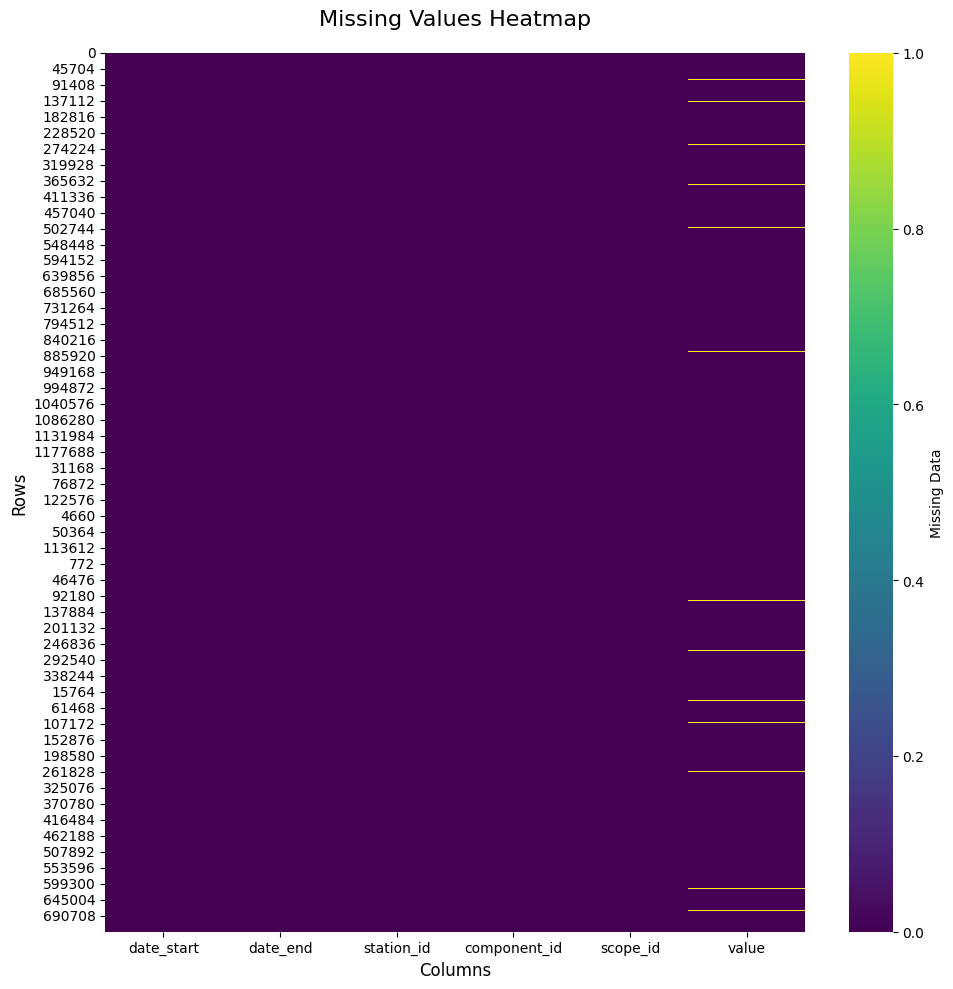

In [36]:
heatmap_missing_values(df_hafen, save_fig= True)